### Cho DataSet lấy từ file C62.csv của các hộ gồm các trường sau:  
- MaLo: mã lô đất  
- MatTien: đường mặt tiền (m) 
- DienTich: diện tích lô đất (m vuông)  
- LoaiDat: loại đất  Loại đất: 1/ 2/ x (x là số năm)_ đất nông nghiệp, đất không thời hạn, đất có thời hạn.  
- Dùng jupyter notebook (hoặc mã nguồn colab) để trả lời các câu hỏi sau.  (Đặt tên file: STT_HoVaTen_MSSV.ipynb và STT_HoVaTen_MSSV.pdf)  

### Câu 1 (3.0 điểm): 
- a. Đọc dữ liệu file trên vào DataFrame có tên df và hiển thị: 5 dòng đầu tiên, 5 dòng ngẫu nhiên, kích thước df, số dòng df, số cột df. 
- b. Thống kê có bao nhiêu lô đất nông nghiệp và đất đất không thời hạn và vẽ biểu đồ pie minh họa. 
- c. In ra giá trị thống kê trung bình (mean) diện tích cho các lô có thời hạn trên 10 năm

In [2]:
#1a
import pandas as pd
dat = pd.read_csv("C62.csv")
print("5 dong dau",dat.head(5))
print("5 dong ngau nhien",dat.sample(5))
print("kich thuoc: ", dat.shape)
print("so dong", dat.shape[0]) #dong
print("so cot: ", dat.shape[1]) #cot

5 dong dau   MaLo  MatTien  DienTich  LoaiDat
0  Lô1        5       120        1
1  Lô2       10       200        2
2  Lô3        7       150       15
3  Lô4        8       180        1
4  Lô5        6       250        2
5 dong ngau nhien     MaLo  MatTien  DienTich  LoaiDat
15  Lô16       10       280        1
9   Lô10       11       350       25
1    Lô2       10       200        2
14  Lô15        8       230       10
11  Lô12        6       270       30
kich thuoc:  (20, 4)
so dong 20
so cot:  4


In [3]:
dat_nong_nghiep = dat[dat['LoaiDat'] == 1]['LoaiDat'].count()
dat_khong_thoi_han = dat[dat['LoaiDat'] == 2]['LoaiDat'].count()
print("dat ko thoi han: ",dat_khong_thoi_han)
print("dat nong nghiep", dat_nong_nghiep)

dat ko thoi han:  6
dat nong nghiep 8


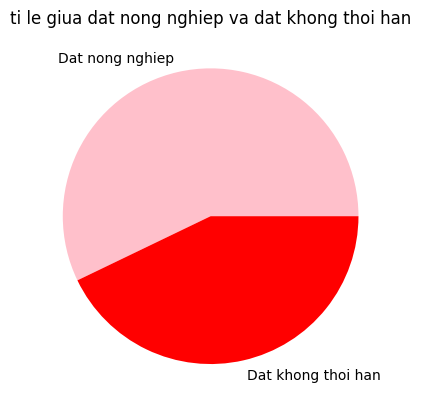

In [5]:
#Ve bieu do
import matplotlib.pyplot as plt
plt.pie([dat_nong_nghiep, dat_khong_thoi_han], labels=['Dat nong nghiep', 'Dat khong thoi han'], colors=['pink','red'])
plt.title("ti le giua dat nong nghiep va dat khong thoi han")
plt.show()



Nhận xét: 
- Số lượng đất nông nghiệp chiếm phần đa

In [9]:
#c
Trung_binh = dat[pd.to_numeric(dat['LoaiDat'])>10]['LoaiDat'].mean()
print(Trung_binh)

25.0


### Câu 2 (2.0 điểm):  Chèn thêm cột Tiền giá trị lô đất (TienGiaDat) (triệu) như sau: 
- Đất nông nghiệp: giá trị lô đất=Diện tích x 2; 
- đất ở không xác định thời hạn: giá trị lô đất =Diện tích lô đất x mặt tiền2, 
- đất có thời hạn: ghi “Không xác định giá trị”; 

In [10]:
dat['LoaiDat'] = dat['LoaiDat'].astype(str)
def tinh_Gia_Dat(row):
    if row['LoaiDat'] == "1":
        return row['DienTich'] *2
    elif row['LoaiDat'] == "2":
        return row['DienTich'] * (row['MatTien'] **2)
    else:
        return "khong xac dinh gia tri"
dat["TienGiaDat"] = dat.apply(tinh_Gia_Dat, axis=1)


In [11]:
dat

,MaLo,MatTien,DienTich,LoaiDat,TienGiaDat
0,Lô1,5,120,1,240
1,Lô2,10,200,2,20000
2,Lô3,7,150,15,khong xac dinh gia tri
3,Lô4,8,180,1,360
4,Lô5,6,250,2,9000
5,Lô6,9,300,20,khong xac dinh gia tri
6,Lô7,4,100,1,200
7,Lô8,3,90,2,810
8,Lô9,12,400,1,800
9,Lô10,11,350,25,khong xac dinh gia tri


### Câu 3 (2.0 điểm):  Chèn thêm cột tiền Chuyển đổi đất (ChuyenDoi)= Diện tích x 15 (triệu).
- Trong đó chỉ chuyển đỗi đất nông nghiệp (LoaiDat=1),
- các loại đất khác thì ghi "Chưa có công văn"   
- Hãy trích lọc ra các lô đất được phép chuyển đổi.  

In [23]:
def chuyenDoiDat(row):
    if row['LoaiDat'] == "1":
        return row['DienTich'] * 15
    else:
        return "chua co cong van"
dat['ChuyenDoi'] = dat.apply(chuyenDoiDat, axis=1)

In [24]:
dat

,MaLo,MatTien,DienTich,LoaiDat,TienGiaDat,ChuyenDoi
0,Lô1,5,120,1,240,1800
1,Lô2,10,200,2,20000,chua co cong van
2,Lô3,7,150,15,khong xac dinh gia tri,chua co cong van
3,Lô4,8,180,1,360,2700
4,Lô5,6,250,2,9000,chua co cong van
5,Lô6,9,300,20,khong xac dinh gia tri,chua co cong van
6,Lô7,4,100,1,200,1500
7,Lô8,3,90,2,810,chua co cong van
8,Lô9,12,400,1,800,6000
9,Lô10,11,350,25,khong xac dinh gia tri,chua co cong van


 ### Câu 4 (3.0 điểm):  
 - a. Giả sử Diện tích có phân phối chuẩn. Hãy xây dựng hàm mật độ xác suất Diện tích 
 - b. Vẽ đồ thị phân phối chuẩn cho Diện tích. Tinh chỉnh xlim, ylim cho đồ thị phù hợp 
 - c. Cho biết bao nhiêu phần trăm lô đất có Diện tích dưới 120 (m vuông). bạn tạo cho tôi tập dữ liệu để tôi thử sức. 

In [25]:
import scipy.stats as stats
import numpy as np